In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

INFILE = Path("FLU_YPD_0.5X_SET2_03_14_26.tsv")

df = pd.read_csv(INFILE, sep="\t")

print("Shape:", df.shape)
df.head()

Shape: (8, 12)


,Unnamed: 0,JAC1-,CKB1-,KAP122-,LEU1-,MPO1-,BRP1-,GET1-,RPN14-,BIL2-,SCL1-,CDH1-
0,FLU -,1.133,0.984,1.027,1.109,2.768,1.219,1.024,2.320,1.255,0.499,1.860
1,FLU -,0.754,0.854,1.139,1.109,2.422,0.618,0.794,2.320,1.046,0.589,1.842
2,FLU -,1.009,1.018,0.583,0.945,2.672,0.714,0.672,2.254,0.730,0.718,2.168
3,FLU -,0.503,0.867,1.190,0.672,2.678,0.469,1.136,1.932,0.453,0.626,0.552
4,FLU +,0.748,0.699,0.414,0.831,1.894,0.481,0.154,1.720,0.589,0.888,0.861


In [16]:
# First column contains condition labels
COND_COL = df.columns[0]

df_plus  = df[df[COND_COL] == "FLU +"].copy()
df_minus = df[df[COND_COL] == "FLU -"].copy()

print("FLU+ rows:", df_plus.shape[0])
print("FLU- rows:", df_minus.shape[0])

FLU+ rows: 4
FLU- rows: 4


In [17]:
# Gene columns = everything except condition column
gene_cols = df.columns[1:]

# Convert to numeric to be safe
df_plus[gene_cols]  = df_plus[gene_cols].apply(pd.to_numeric, errors="coerce")
df_minus[gene_cols] = df_minus[gene_cols].apply(pd.to_numeric, errors="coerce")

# Mean across replicates
mean_plus  = df_plus[gene_cols].mean()
mean_minus = df_minus[gene_cols].mean()

mean_plus.head()

JAC1-      0.78000
CKB1-      0.67550
KAP122-    0.42125
LEU1-      0.66725
MPO1-      2.03900
dtype: float64

In [18]:
PSEUDOCOUNT = 0  # change to 1 if zeros are possible

FD = np.log10((mean_plus + PSEUDOCOUNT) / (mean_minus + PSEUDOCOUNT))

fd_df = pd.DataFrame({
    "Gene": gene_cols,
    "Mean_FLU_plus": mean_plus.values,
    "Mean_FLU_minus": mean_minus.values,
    "FD_score": FD.values
})

fd_df = fd_df.sort_values("FD_score")

fd_df

,Gene,Mean_FLU_plus,Mean_FLU_minus,FD_score
10,CDH1-,0.61200,1.60550,-0.418859
7,RPN14-,0.87275,2.20650,-0.402814
2,KAP122-,0.42125,0.98475,-0.368786
3,LEU1-,0.66725,0.95875,-0.157417
1,CKB1-,0.67550,0.93075,-0.139208
8,BIL2-,0.67150,0.87100,-0.112972
4,MPO1-,2.03900,2.63500,-0.111363
6,GET1-,0.70625,0.90650,-0.108409
0,JAC1-,0.78000,0.84975,-0.037197
9,SCL1-,0.83350,0.60800,0.137002


In [19]:
OUTFILE = Path("Output/FLU_YPD_0.5X_SET2_meanFD.tsv")
fd_df.to_csv(OUTFILE, sep="\t", index=False)

print("Saved:", OUTFILE)

Saved: Output/FLU_YPD_0.5X_SET2_meanFD.tsv


In [20]:
# Safety check: same number of replicates
if df_plus.shape[0] != df_minus.shape[0]:
    raise ValueError(
        f"Mismatch in replicate counts: "
        f"{df_plus.shape[0]} FLU+ vs {df_minus.shape[0]} FLU-"
    )

n_reps = df_plus.shape[0]
print("Number of replicate pairs:", n_reps)

PSEUDOCOUNT = 0  # set to 1 if zeros possible

# Store per-replicate FD values
fd_rep_list = []

for i in range(n_reps):
    plus_vals  = df_plus.iloc[i][gene_cols].astype(float)
    minus_vals = df_minus.iloc[i][gene_cols].astype(float)

    fd_rep = np.log10((plus_vals + PSEUDOCOUNT) /
                      (minus_vals + PSEUDOCOUNT))

    fd_rep_list.append(fd_rep)

# Convert to DataFrame
fd_rep_df = pd.DataFrame(fd_rep_list)
fd_rep_df.columns = gene_cols
fd_rep_df.index = [f"Rep_{i+1}" for i in range(n_reps)]

fd_rep_df

Number of replicate pairs: 4


,JAC1-,CKB1-,KAP122-,LEU1-,MPO1-,BRP1-,GET1-,RPN14-,BIL2-,SCL1-,CDH1-
Rep_1,-0.180328,-0.148518,-0.394570,-0.125331,-0.164786,-0.403859,-0.822779,-0.129960,-0.328528,0.250312,-0.334510
Rep_2,-0.161368,0.110329,-0.292348,-0.082562,-0.002879,-0.107041,-0.009399,-0.578028,-0.396282,0.031974,-0.455730
Rep_3,-0.595651,-0.399222,-0.179081,-0.297825,-0.145349,0.563275,0.161190,-0.717470,-0.052419,0.091799,-0.767858
Rep_4,0.501465,-0.242537,-0.592673,-0.179009,-0.139114,0.679463,-0.091591,-0.425071,0.356739,0.169567,0.015457


In [21]:
OUTFILE_REP = Path("Output/FLU_YPD_0.5X_SET2_FD_per_replicate.tsv")
fd_rep_df.to_csv(OUTFILE_REP, sep="\t")

print("Saved:", OUTFILE_REP)

Saved: Output/FLU_YPD_0.5X_SET2_FD_per_replicate.tsv


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose error bar type: "sd" or "sem"
ERROR_BARS = "sd"   # change to "sem" if you prefer SEM

fd_mean = fd_rep_df.mean(axis=0)
fd_sd   = fd_rep_df.std(axis=0, ddof=1)
fd_sem  = fd_sd / np.sqrt(fd_rep_df.shape[0])

summary = pd.DataFrame({
    "Gene": fd_rep_df.columns,
    "FD_mean": fd_mean.values,
    "FD_sd": fd_sd.values,
    "FD_sem": fd_sem.values
}).sort_values("FD_mean").reset_index(drop=True)

summary

,Gene,FD_mean,FD_sd,FD_sem
0,RPN14-,-0.462632,0.251887,0.125943
1,CDH1-,-0.385660,0.323778,0.161889
2,KAP122-,-0.364668,0.175645,0.087822
3,GET1-,-0.190645,0.434374,0.217187
4,LEU1-,-0.171182,0.093194,0.046597
5,CKB1-,-0.169987,0.213581,0.106790
6,MPO1-,-0.113032,0.074245,0.037122
7,JAC1-,-0.108971,0.453625,0.226812
8,BIL2-,-0.105123,0.341944,0.170972
9,SCL1-,0.135913,0.094814,0.047407


In [23]:
import matplotlib as mpl

mpl.rcParams.update({

    # Font sizes
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,

    # Make axis labels bold
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",

    # Thicker axes lines
    "axes.linewidth": 1.5,

    # Thicker ticks
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

})

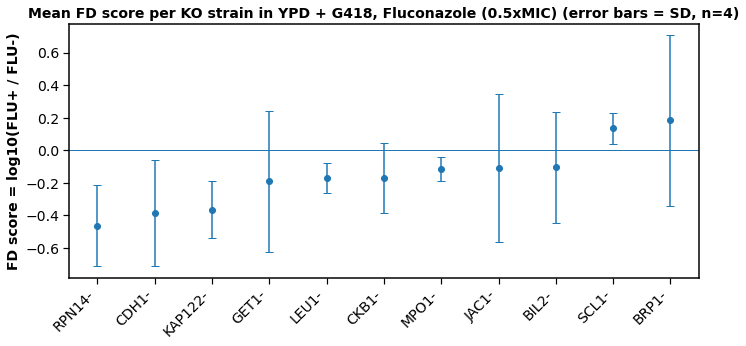

In [24]:
yerr = summary["FD_sd"].to_numpy() if ERROR_BARS == "sd" else summary["FD_sem"].to_numpy()

x = np.arange(summary.shape[0])

plt.figure(figsize=(max(10, 0.8 * len(summary)), 5))
plt.errorbar(
    x,
    summary["FD_mean"].to_numpy(),
    yerr=yerr,
    fmt="o",
    capsize=4
)

plt.axhline(0, linewidth=1)
plt.xticks(x, summary["Gene"].tolist(), rotation=45, ha="right")
plt.ylabel("FD score = log10(FLU+ / FLU-)")
plt.title(f"Mean FD score per KO strain in YPD + G418, Fluconazole (0.5xMIC) (error bars = {ERROR_BARS.upper()}, n={fd_rep_df.shape[0]})")
plt.tight_layout()
plt.show()

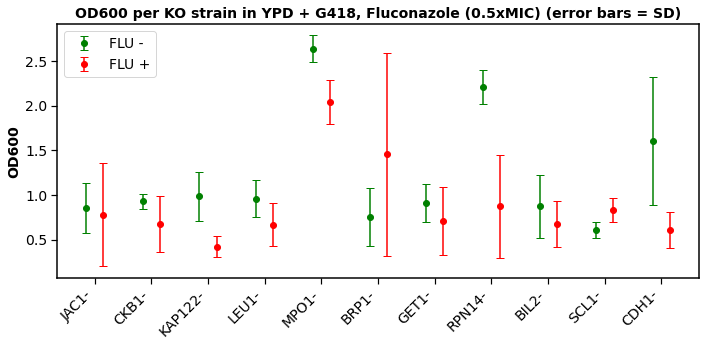

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Error bar type: "sd" or "sem"
ERROR_BARS = "sd"

COND_COL = df.columns[0]
gene_cols = df.columns[1:]

# Split conditions
df_minus = df[df[COND_COL] == "FLU -"].copy()
df_plus  = df[df[COND_COL] == "FLU +"].copy()

# Ensure numeric
df_minus[gene_cols] = df_minus[gene_cols].apply(pd.to_numeric, errors="coerce")
df_plus[gene_cols]  = df_plus[gene_cols].apply(pd.to_numeric, errors="coerce")

# Compute means
mean_minus = df_minus[gene_cols].mean()
mean_plus  = df_plus[gene_cols].mean()

# Compute variability
sd_minus = df_minus[gene_cols].std(ddof=1)
sd_plus  = df_plus[gene_cols].std(ddof=1)

sem_minus = sd_minus / np.sqrt(df_minus.shape[0])
sem_plus  = sd_plus  / np.sqrt(df_plus.shape[0])

err_minus = sd_minus if ERROR_BARS == "sd" else sem_minus
err_plus  = sd_plus  if ERROR_BARS == "sd" else sem_plus

# X positions
x = np.arange(len(gene_cols))
offset = 0.15  # small horizontal shift

plt.figure(figsize=(max(10, 0.8 * len(gene_cols)), 5))

# Plot FLU -
plt.errorbar(
    x - offset,
    mean_minus.values,
    yerr=err_minus.values,
    fmt="o",
    capsize=4,
    color="green",
    ecolor="green",
    label="FLU -"
)

# Plot FLU +
plt.errorbar(
    x + offset,
    mean_plus.values,
    yerr=err_plus.values,
    fmt="o",
    capsize=4,
    color="red",
    ecolor="red",
    label="FLU +"
)

plt.xticks(x, gene_cols, rotation=45, ha="right")
plt.ylabel("OD600")
plt.title(f"OD600 per KO strain in YPD + G418, Fluconazole (0.5xMIC) (error bars = {ERROR_BARS.upper()})")
plt.legend()
plt.tight_layout()
plt.show()